In [470]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [471]:
heart_dataset = pd.read_csv("C:/Documants/projects/Datasets/heart_disease_uci.csv")



heart_dataset.info()



<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [472]:

heart_dataset.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

We cleaned the heart disease dataset by removing rows with missing values in columns like chol, trestbps, restecg, and oldpeak since the number of missing values was small. For columns like fbs, ca, slope, and thal, which had a large number of missing values, we filled them using mode or "unknown" to avoid losing too much data. We also converted fbs and exang to integer type to make the dataset consistent and ready for machine learning.

In [473]:
heart_dataset = heart_dataset.dropna(subset=["chol"])
heart_dataset = heart_dataset.dropna(subset=["trestbps"])
heart_dataset = heart_dataset.dropna(subset=["restecg"])
heart_dataset = heart_dataset.dropna(subset=["oldpeak"])
heart_dataset["fbs"] = heart_dataset["fbs"].fillna(
    heart_dataset["fbs"].mode()[0]
)
heart_dataset["ca"] = heart_dataset["ca"].fillna(
    heart_dataset["ca"].mode()[0]
)
heart_dataset["fbs"] = heart_dataset["fbs"].astype(int)
heart_dataset["exang"] = heart_dataset["exang"].astype(int)
heart_dataset["slope"] = heart_dataset["slope"].fillna("unknown")
heart_dataset["thal"] = heart_dataset["thal"].fillna("unknown")


In [474]:
heart_dataset.duplicated().sum()

np.int64(0)

As it aslo dont have any Duplicate values. We can see for leading and trailing spaces.

In [475]:
for col in heart_dataset.columns:
    # check if column has any string values
    if heart_dataset[col].apply(lambda x: isinstance(x, str)).any():
        mask = heart_dataset[col] != heart_dataset[col].str.strip()
        
        if mask.any():
            print(f"Column '{col}' has leading/trailing spaces")

As three Column 'restecg' , 'slope' and 'thal' has leading/trailing spaces we will remove it. 

In [476]:
cols = ["restecg", "slope", "thal"]
for col in cols:
    heart_dataset[col] = heart_dataset[col].astype("string").str.strip()

# Now checking

for col in heart_dataset.columns:
    # check if column has any string values
    if heart_dataset[col].apply(lambda x: isinstance(x, str)).any():
        mask = heart_dataset[col] != heart_dataset[col].str.strip()
        
        if mask.any():
            print(f"Column '{col}' has leading/trailing spaces")
        else:
            print("No leading and trailing space")

No leading and trailing space
No leading and trailing space
No leading and trailing space
No leading and trailing space
No leading and trailing space
No leading and trailing space


Now We will check for inconscitency

In [477]:
for col in heart_dataset.select_dtypes(include=["object", "string"]).columns:
    print("\n", col)
    print(heart_dataset[col].apply(lambda x: str(x).strip()).unique())


 sex
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

 dataset
<ArrowStringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str

 cp
<ArrowStringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str

 restecg
<ArrowStringArray>
['lv hypertrophy', 'normal', 'st-t abnormality']
Length: 3, dtype: str

 slope
<ArrowStringArray>
['downsloping', 'flat', 'upsloping', 'unknown']
Length: 4, dtype: str

 thal
<ArrowStringArray>
['fixed defect', 'normal', 'reversable defect', 'unknown']
Length: 4, dtype: str


In [478]:
def map_classes(x):
    if x == 0:
        return 0
    else:
        return 1


heart_dataset["num"] = heart_dataset["num"].apply(map_classes)

heart_dataset["sex"] = heart_dataset["sex"].map({
    "Male": 1,
    "Female": 0
})



Our Dataset is consistent no need to change any thing here. Now we can move to anaylisis of the data
- First finding the mean, median , minimum and maximum value and visulizing the distribution of all the column
- Second finding correlation and visulizing it.

Starting with mean, median, minimum and maximum value

In [479]:
heart_dataset.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0.0,fixed defect,0
1,2,67,1,Cleveland,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3.0,normal,1
2,3,67,1,Cleveland,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2.0,reversable defect,1
3,4,37,1,Cleveland,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0
4,5,41,0,Cleveland,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0


In [480]:
heart_dataset.info()


<class 'pandas.DataFrame'>
Index: 825 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        825 non-null    int64  
 1   age       825 non-null    int64  
 2   sex       825 non-null    int64  
 3   dataset   825 non-null    str    
 4   cp        825 non-null    str    
 5   trestbps  825 non-null    float64
 6   chol      825 non-null    float64
 7   fbs       825 non-null    int64  
 8   restecg   825 non-null    string 
 9   thalch    825 non-null    float64
 10  exang     825 non-null    int64  
 11  oldpeak   825 non-null    float64
 12  slope     825 non-null    string 
 13  ca        825 non-null    float64
 14  thal      825 non-null    string 
 15  num       825 non-null    int64  
dtypes: float64(5), int64(6), str(2), string(3)
memory usage: 148.0 KB


In [481]:
heart_dataset.drop(columns=['id', 'exang', 'fbs']).describe()

,age,sex,trestbps,chol,thalch,oldpeak,ca,num
count,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000
mean,53.209697,0.775758,132.098182,201.073939,137.724848,0.885212,0.253333,0.550303
std,9.335359,0.417335,19.040868,109.953545,25.856178,1.094636,0.659189,0.497765
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,46.000000,1.000000,120.000000,178.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,224.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,1.000000,140.000000,268.000000,157.000000,1.500000,0.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


While the dataset appears complete, several physiological variables such as resting blood pressure and cholesterol contain invalid zero values, indicating missing data encoded as zero. These values may bias statistical measures such as mean and standard deviation.

In [482]:
heart_dataset[['trestbps', 'chol']] = heart_dataset[['trestbps', 'chol']].replace(0, np.nan)
heart_dataset['trestbps'] = heart_dataset['trestbps'].fillna(heart_dataset['trestbps'].median())
heart_dataset['chol'] = heart_dataset['chol'].fillna(heart_dataset['chol'].median())

heart_dataset.drop(columns=['id', 'exang', 'fbs']).describe()

,age,sex,trestbps,chol,thalch,oldpeak,ca,num
count,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000
mean,53.209697,0.775758,132.255758,245.873939,137.724848,0.885212,0.253333,0.550303
std,9.335359,0.417335,18.475878,52.983636,25.856178,1.094636,0.659189,0.497765
min,28.000000,0.000000,80.000000,85.000000,60.000000,-2.600000,0.000000,0.000000
25%,46.000000,1.000000,120.000000,216.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,240.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,1.000000,140.000000,268.000000,157.000000,1.500000,0.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


the distribution can visulize as folows

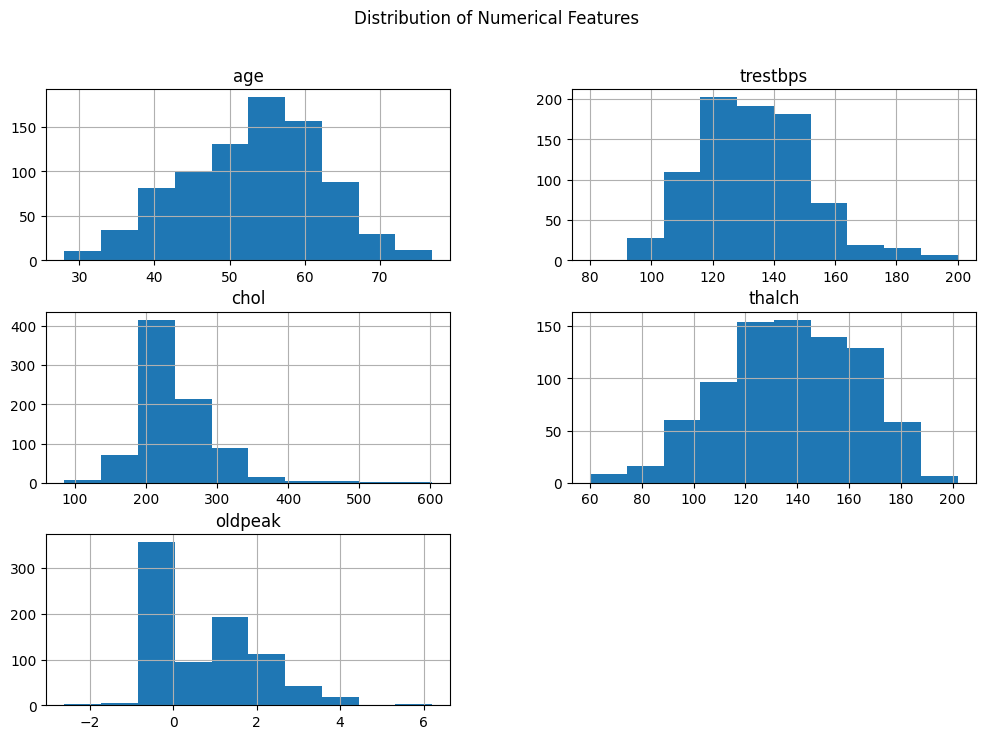

In [483]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

heart_dataset[num_cols].hist(figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

Age, resting blood pressure, and maximum heart rate show approximately normal distributions with mild skewness, which is expected in physiological datasets. In contrast, cholesterol and oldpeak exhibit strong right skewness, indicating the presence of extreme values and non-normal biological variation among patients

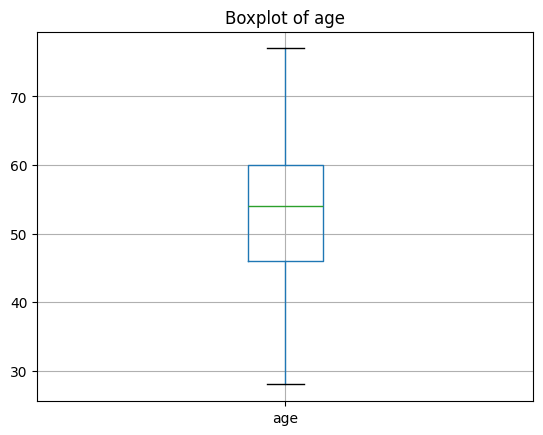

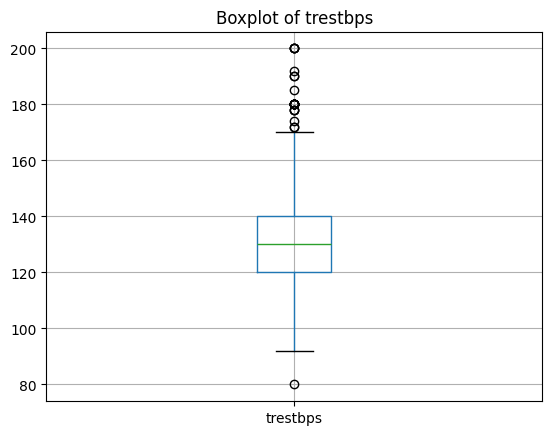

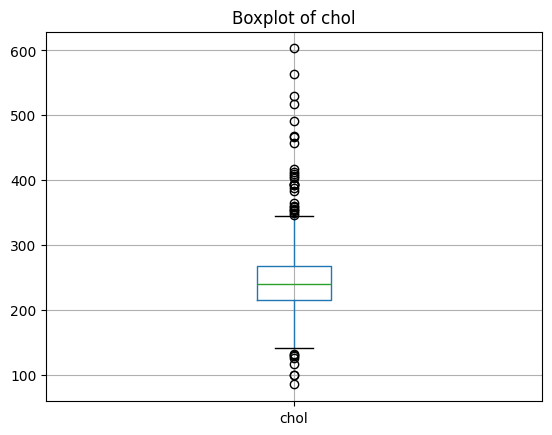

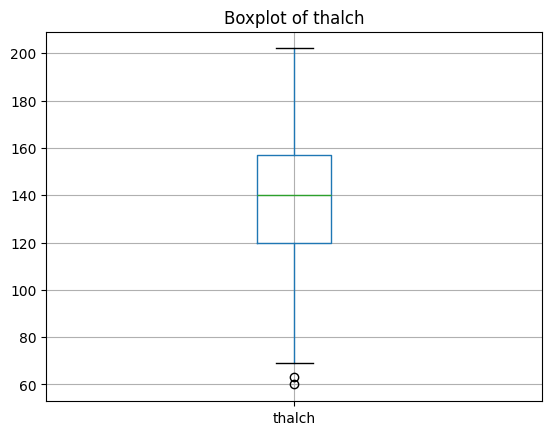

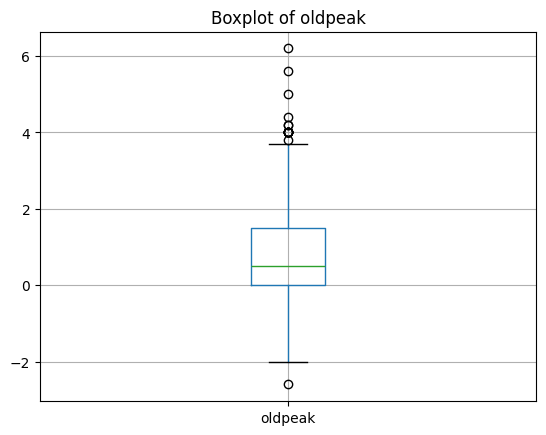

In [484]:

for col in num_cols:
    plt.figure()
    heart_dataset.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

the boxplots show that most variables like age, thalch, and trestbps are fairly concentrated around their median values with relatively small spread. Cholesterol and oldpeak show strong right-skewness with several high outliers, indicating extreme patient conditions.few medical variables contain significant outliers that reflect high-risk cardiac cases.

Now seeing correletion

In [485]:
corr = heart_dataset.corr(numeric_only=True)
print(corr)

                id       age       sex  trestbps      chol       fbs  \
id        1.000000  0.191508  0.251174  0.066514 -0.018027  0.092511   
age       0.191508  1.000000  0.033578  0.263897  0.070947  0.207014   
sex       0.251174  0.033578  1.000000  0.007132 -0.096723  0.058687   
trestbps  0.066514  0.263897  0.007132  1.000000  0.080749  0.161712   
chol     -0.018027  0.070947 -0.096723  0.080749  1.000000  0.057959   
fbs       0.092511  0.207014  0.058687  0.161712  0.057959  1.000000   
thalch   -0.475375 -0.362606 -0.167789 -0.112535 -0.025384 -0.037178   
exang     0.253716  0.209217  0.177711  0.159321  0.073832  0.045601   
oldpeak   0.038094  0.250283  0.102979  0.180507  0.047308  0.053061   
ca       -0.379185  0.248126 -0.027057  0.036126  0.066901  0.085624   
num       0.369321  0.277828  0.302652  0.121520  0.085922  0.092229   

            thalch     exang   oldpeak        ca       num  
id       -0.475375  0.253716  0.038094 -0.379185  0.369321  
age      -0.3

Correlation analysis shows that oldpeak (0.43) and exang (0.39) have the strongest positive correlation with the target variable, while thalch (-0.36) shows a moderate negative correlation. Age (0.33) and ca (0.29) also have positive relationships with the target variable. Cholesterol (0.03) and fasting blood sugar (0.10) show weak linear relationships. This suggests the dataset contains both linear and non-linear patterns, making tree-based models more suitable.

we can visulize it by heat map

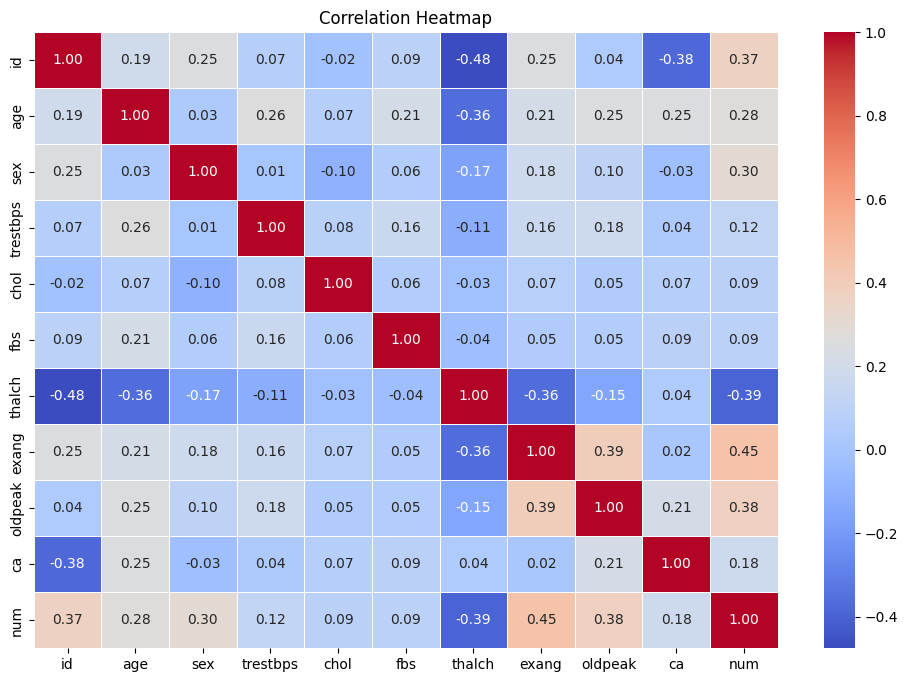

In [486]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

by correletion matrix we can make selected feature set wich is highly coreleted with num and also add some weak attribute as well 


In [487]:
selected_features = [
    'oldpeak',
    'exang',
    'thalch',
    'age',
    'sex',
    'ca',
    'trestbps',
    'chol',
    'fbs'
]

Now we can start with training and testing model the model. first specifying X and Y for our model. X is slected feature and Y is our target variable wich is 'num'

In [488]:
X = heart_dataset[selected_features]
y = heart_dataset['num']

In [489]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

smote = SMOTE(random_state=42)
# -------------------------
# Split the dataset
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# Scale data for Logistic Regression
# -------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Define models
# -------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    )
}

# -------------------------
# Cross-validation results
# -------------------------
print("\n==============================")
print("Cross-Validation Results")
print("==============================")

for name, model in models.items():

    if name == "Logistic Regression":
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

    print(f"\n{name}")
    print(f"Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")



Cross-Validation Results

Random Forest
Mean accuracy: 0.7864 (+/- 0.0458)

Gradient Boosting
Mean accuracy: 0.7773 (+/- 0.0403)

Logistic Regression
Mean accuracy: 0.7758 (+/- 0.0360)


In [490]:

# -------------------------
# Final model evaluation (Random Forest)
# -------------------------
print("\n==============================")
print("Final Evaluation - Random Forest")
print("==============================")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# probabilities (THIS is your % risk)
y_proba = rf.predict_proba(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred,
      target_names=["No Disease", " Disease"]))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------
# Overall performance
# -------------------------
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted"
)

print("\nOverall performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Final Evaluation - Random Forest

Classification report:
              precision    recall  f1-score   support

  No Disease       0.72      0.68      0.70        74
     Disease       0.75      0.79      0.77        91

    accuracy                           0.74       165
   macro avg       0.74      0.73      0.73       165
weighted avg       0.74      0.74      0.74       165


Confusion matrix:
[[50 24]
 [19 72]]

Overall performance:
Accuracy: 0.7394
Precision: 0.7386
Recall: 0.7394
F1-score: 0.7383


and test accuracy (0.6485). It showed strong performance on “No Disease” and “Mild Disease” classes, but struggled with the minority “Severe Disease” class due to imbalance and overlapping features. Overall, the results indicate that ensemble methods capture the dataset structure better than linear models, though prediction for severe cases remains challenging.

In [491]:
import joblib

joblib.dump(rf, "heartdieses_rf_model.pkl")

['heartdieses_rf_model.pkl']